# Minimize the Pairwise Distance Ratio for N Points
[![min_pairw_dist_ratio.ipynb](https://img.shields.io/badge/github-%23121011.svg?logo=github)](https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/min_pairwise_distance_ratio/min_pairw_dist_ratio.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/min_pairwise_distance_ratio/min_pairw_dist_ratio.ipynb) [![Open In Deepnote](https://deepnote.com/buttons/launch-in-deepnote-small.svg)](https://deepnote.com/launch?url=https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/min_pairwise_distance_ratio/min_pairw_dist_ratio.ipynb) [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/min_pairwise_distance_ratio/min_pairw_dist_ratio.ipynb) [![Open In Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/min_pairwise_distance_ratio/min_pairw_dist_ratio.ipynb) [![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/min_pairwise_distance_ratio/min_pairw_dist_ratio.ipynb) [![Powered by AMPL](https://h.ampl.com/https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/min_pairwise_distance_ratio/min_pairw_dist_ratio.ipynb)](https://ampl.com)

Description: Minimize the pairwise distance ratio of N points with FICO Xpress

Tags: AMPLPY, highlights, nonlinear, quadratic, global optimization, local optimization, trigonometric, xpress

Notebook author: Gleb Belov <<gleb@ampl.com>>

Reference:

1. FICO Xpress nonlinear examples. https://www.fico.com/fico-xpress-optimization/docs/latest/examples/mosel/NonLinear/, accessed Feb 27, 2026.
2. AMPL Xpress documentation. [https://dev.ampl.com/solvers/xpress](https://dev.ampl.com/solvers/xpress).

In [1]:
# Install dependencies
%pip install -q amplpy pandas matplotlib

In [2]:
# Google Colab & Kaggle integration
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["xpress"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

## Overview

We consider a minimum pairwise distance ratio problem from [1]. We shell solve it with the Xpress local and global optimizers. For the local optimizer we will see how important it is to provide a reasonable starting point.

## Use `%%ampl_eval` to evaluate AMPL commands and declarations

In [3]:
%%ampl_eval

# Parameters
param N default 12;       # Number of points to be placed, eg 12, 14 or 16
param D default 3;        # Number of dimensions: 2, 3, ...

# Public declarations
set POINTS := 1..N;
set DIMS := 1..D;

# Variables
var x {POINTS, DIMS} >=0 <=1;   # N points in D-dimensional space
var t_min >=0 <=1;              # Variable for min squared distance
 
# Constraints on distances
s.t. DistLB {i in POINTS, j in POINTS: i<j}:
    sum {k in DIMS} (x[i, k] - x[j,k])^2 >= t_min;
s.t. DistUB {i in POINTS, j in POINTS: i<j}:
    sum {k in DIMS} (x[i, k] - x[j,k])^2 <= 1;

# We wish to minimize 1/t_min, which is invariant for scaling.
# Instead, we can improve the formulation by
# maximizing t_min (with this reformulation we are turning the problem 
# from a general nonlinear problem into a non-convex quadratic programming 
# problem).
maximize Obj: t_min;


## Load data directly from Python data structures using [amplpy](https://amplpy.readthedocs.io/)

In [4]:
N = 12
D = 3

ampl.param["N"] = N
ampl.param["D"] = D

## Local optimization: solve with Xpress SLP

In [5]:
ampl.option["solver"] = "xpress"
ampl.option["mp_options"] = "outlev=1 alg:nlpsolver=1 alg:localsolver=0"

ampl.snapshot(
    "min_pairw_snapshot_0.run"
)  # Debug feature, saves AMPL state including the model

ampl.solve()

XPRESS 9.8.0 (46.01.01):   tech:outlev = 1
  alg:nlpsolver = 1
  alg:localsolver = 0

AMPL MP initial flat model has 37 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  132 quadratic;

AMPL MP final model has 37 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  132 quadratic;


Original problem size
   linear:    132 rows, 37 columns, 66 linear coefficients
   quadratic: 0 in obj, 132 rows, 1188 in rows
Nonlinear presolve
   converted 66 quadratic matrices to formulas
   simplify removed 792 tokens
   creating 66 '+' clusters removed 396 tokens
Presolved problem size
   linear:    132 rows, 38 columns, 66 linear coefficients
   quadratic: 0 in obj, 66 rows, 594 in rows
   nonlinear: 66 coefficients, 2310 tokens
             396 mul             0 div         0 sqrt
               0 exp             0 log       396 pow
Problem is nonlinear presolved
FICO Xpress v9.8.0, Hyper, solve started 17:29:47, Mar 3, 2026
Control settings used:
INPUTTOL = 0
L

### Retrieve solution and visualize

In [6]:
import matplotlib.pyplot as plt
import numpy as np


def display_solution(ampl):
    print("\nAMPL solve result:", ampl.solve_result, " code:", ampl.solve_result_num)
    print("Objective value:", ampl.get_objective("Obj").value(), "\n")
    df_x = ampl.var["x"].to_pandas().unstack().transpose()
    display(df_x)

    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")

    ax.scatter(df_x.iloc[0, :], df_x.iloc[1, :], df_x.iloc[2, :])

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.show()


AMPL solve result: limit  code: 400
Objective value: 5.999487782228242e-05 



index0              1         2         3         4         5         6   \
      index1                                                               
x.val 1       0.000014  0.000014  0.000014  0.000014  0.000014  0.000014   
      2       0.000014  0.000014  0.000014  0.000014  0.000014  0.000014   
      3       0.000014  0.000014  0.000014  0.000014  0.000014  0.000014   

index0              7         8         9         10        11        12  
      index1                                                              
x.val 1       0.000014  0.000014  0.000014  0.000014  0.000014  0.000014  
      2       0.000014  0.000014  0.000014  0.000014  0.000014  0.000014  
      3       0.000014  0.000014  0.000014  0.000014  0.000014  0.000014

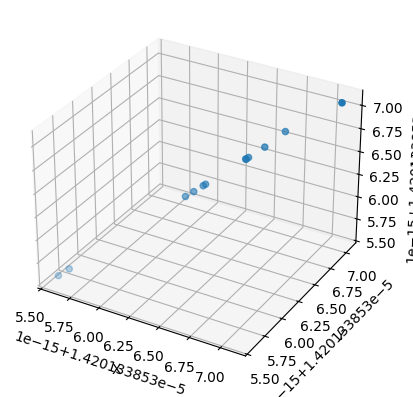

In [7]:
display_solution(ampl)

## Provide a starting point to escape the local optimum

In [8]:
import random
import numpy as np
import pandas as pd

random.seed(42)
start = np.random.rand(N, D)

start_df = pd.DataFrame(start, index=range(1, N + 1), columns=range(1, D + 1))
start_df.transpose()

,1,2,3,4,5,6,7,8,9,10,11,12
1,0.309670,0.816174,0.072489,0.788642,0.573822,0.766945,0.127842,0.617298,0.238040,0.819574,0.517516,0.908738
2,0.247674,0.360498,0.616121,0.555726,0.606850,0.398702,0.438036,0.954704,0.680294,0.025726,0.412743,0.436167
3,0.001503,0.812331,0.767304,0.032685,0.373634,0.522982,0.186059,0.567483,0.924209,0.857128,0.339448,0.973921


In [9]:
ampl.get_variable("x").set_values(start_df)

ampl.option["mp_options"] = "outlev=1 alg:nlpsolver=1 alg:localsolver=0"
# ampl.snapshot('min_pairw_snapshot_1__with_random_start.run')

ampl.solve()

XPRESS 9.8.0 (46.01.01):   tech:outlev = 1
  alg:nlpsolver = 1
  alg:localsolver = 0

AMPL MP initial flat model has 37 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  132 quadratic;

AMPL MP final model has 37 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  132 quadratic;


User solution (AMPL_initial_guess) stored.
Original problem size
   linear:    132 rows, 37 columns, 66 linear coefficients
   quadratic: 0 in obj, 132 rows, 1188 in rows
Nonlinear presolve
   converted 66 quadratic matrices to formulas
   simplify removed 792 tokens
   creating 66 '+' clusters removed 396 tokens
Presolved problem size
   linear:    132 rows, 38 columns, 66 linear coefficients
   quadratic: 0 in obj, 66 rows, 594 in rows
   nonlinear: 66 coefficients, 2310 tokens
             396 mul             0 div         0 sqrt
               0 exp             0 log       396 pow
Problem is nonlinear presolved
FICO Xpress v9.8.0, Hyper, solve started 17:29:47, Mar 3,

### Retrieve the improved local solution


AMPL solve result: limit  code: 400
Objective value: 0.2696777840853675 



index0              1         2         3         4         5         6   \
      index1                                                               
x.val 1       0.320639  0.951813  0.053109  0.664496  0.858774  0.817438   
      2       0.083250  0.159550  0.361453  0.661393  0.914987  0.163964   
      3       0.294013  0.667730  0.641445  0.021066  0.430485  0.166131   

index0              7         8         9         10        11        12  
      index1                                                              
x.val 1       0.179595  0.351550  0.392611  0.457261  0.580566  0.894054  
      2       0.570608  0.943895  0.563611  0.078762  0.482232  0.653852  
      3       0.183261  0.571597  0.978415  0.804002  0.501206  0.877969

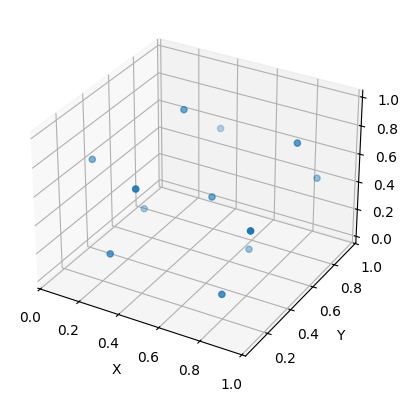

In [10]:
display_solution(ampl)

## Solve with Xpress Global (reusing previous solution)

This invokes the global optimizer.

In [11]:
ampl.option["solver"] = "xpress"
ampl.option["mp_options"] = "outlev=1 lim:time=30"
ampl.solve()

XPRESS 9.8.0 (46.01.01):   tech:outlev = 1
  lim:time = 30

AMPL MP initial flat model has 37 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  132 quadratic;

AMPL MP final model has 37 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  132 quadratic;


User solution (AMPL_initial_guess) stored.
Original problem size
   linear:    132 rows, 37 columns, 66 linear coefficients
   quadratic: 0 in obj, 132 rows, 1188 in rows
Nonlinear presolve
   converted 66 quadratic matrices to formulas
   simplify removed 792 tokens
   creating 66 '+' clusters removed 396 tokens
Presolved problem size
   linear:    132 rows, 38 columns, 66 linear coefficients
   quadratic: 0 in obj, 66 rows, 594 in rows
   nonlinear: 66 coefficients, 2310 tokens
             396 mul             0 div         0 sqrt
               0 exp             0 log       396 pow
Problem is nonlinear presolved
FICO Xpress v9.8.0, Hyper, solve started 17:29:47, Mar 3, 2026
Control settings use

### Retrieve the solution from Xpress Global


AMPL solve result: limit  code: 400
Objective value: 0.2763932056861722 



index0              1         2         3         4         5         6   \
      index1                                                               
x.val 1       0.532567  0.721104  0.114947  0.885053  0.278896  0.045381   
      2       0.908340  0.443782  0.818349  0.181651  0.556218  0.298173   
      3       0.786701  0.944919  0.480289  0.519711  0.055081  0.449133   

index0              7         8         9         10        11        12  
      index1                                                              
x.val 1       0.579993  0.797842  0.467433  0.420007  0.954619  0.202158  
      2       0.933322  0.484204  0.091660  0.066678  0.701827  0.515796  
      3       0.263710  0.098701  0.213299  0.736290  0.550867  0.901299

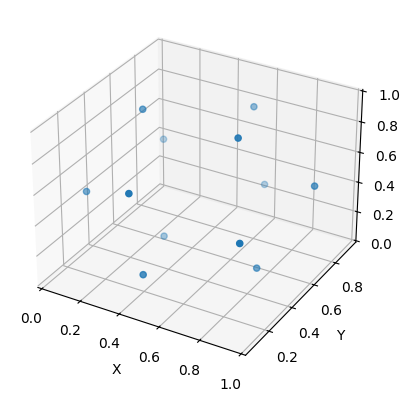

In [12]:
display_solution(ampl)

# Conclusion

We observed that local optimization (e.g., Xpress SLP) can quickly provide good solutions to nonlinear problems, but may require "reasonable" starting points. Xpress Global Optimizer can improve the result, taking longer time.